# Proportional Cartograms

This tutorial covers proportional cartograms created through shape splitting and shrinking, which divide geometries to represent multiple data dimensions and proportions within areas.

## What You'll Learn

- Split or shrink shapes to represent proportional data
- Use batch processing with `partition_geometries` for efficient workflows
- Visualize partitioned data with `plot_partitions`

## Prerequisites

Install **carto-flow** first. For the examples, we use data from the US Census Bureau. The [censusdis](https://github.com/censusdis/censusdis) package offers a convenient interface for downloading this data.

In [13]:
# Install prerequisites (run this once in your terminal)
# pip install carto-flow
# pip install censusdis

## Step 1: Import Libraries

In [30]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import Polygon
from shapely.plotting import plot_polygon

import carto_flow.data as examples
import carto_flow.proportional_cartogram as pc

## Step 2: Helper Functions

### Helper Function to Plot Split Geometries

In [31]:
def plot_parts(parts, ncolumns=2, label=True, cmap="Wistia"):
    n = len(parts)
    nrows = int(np.ceil(n / ncolumns))

    _fig, axes = plt.subplots(
        nrows, ncolumns, figsize=(3 * ncolumns, 2 * nrows), sharex=True, sharey=True, squeeze=False
    )

    for ax, (key, part) in zip(axes.ravel(), parts.items(), strict=False):
        if not isinstance(part, list):
            part = [part]

        areas = np.array([p.area for p in part])
        areas = areas / np.sum(areas)

        cm = mpl.colormaps[cmap]
        colors = cm(np.linspace(0, 1, len(part)))

        for p, a, c in zip(part, areas, colors, strict=False):
            plot_polygon(p, ax=ax, edgecolor="black", facecolor=c, alpha=0.5, add_points=False)
            if label:
                ax.text(p.centroid.x, p.centroid.y, f"{a:.0%}", ha="center", va="center")

        ax.set_title(key)
        ax.axis("off")

    for ax in axes.ravel()[n:]:
        ax.remove()

## Step 3: Basic Splitting

The `split` function splits a single geometry into multiple parts, each taking up a user-specified fraction of the geometry's total area. Let's define a simple polygon to show how the `split` function works.

In [32]:
# Create a simple polygon
polygon = Polygon([(0, 0), (10, 0), (10, 5), (0, 5)])

### Split a Geometry into Two Parts

To split a geometry into two parts, you would provide a list of two fractions that must sum to one, for example, [0.6, 0.4]. Alternatively, as a short-hand, you can provide a single fraction _f_ and the other fraction is automatically calculated as _1-f_. By default, the `split` function splits geometries vertically, but you can explicitly set the orientation of the splits (vertical or horizontal) by specifying the `direction` parameter. Vertical splits are ordered left-to-right, and horizontal splits are ordered bottom-to-top.

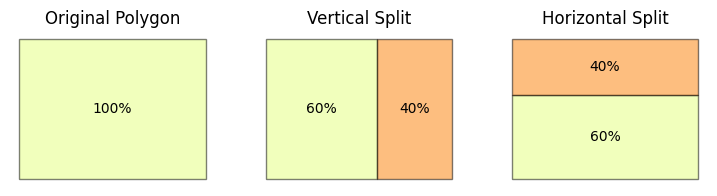

In [33]:
# Split into two parts that take 60% and 40% of the polygon's area
vsplit = pc.split(polygon, fractions=0.6)
hsplit = pc.split(polygon, fractions=0.6, direction="horizontal")

plot_parts(
    {
        "Original Polygon": polygon,
        "Vertical Split": vsplit,
        "Horizontal Split": hsplit,
    },
    ncolumns=3,
)

### Multiple Splits

To split a geometry into three or more parts, provide a list of fractions that sum to one, such as [0.3, 0.3, 0.4] for three parts or [0.1, 0.15, 0.25, 0.15, 0.35] for five parts. Use the `alternate` parameter to control whether splits alternate direction with each step or maintain a consistent direction (creating strip-like regions). When `alternate=True`, the direction of the first split is specified by the `direction` parameter.

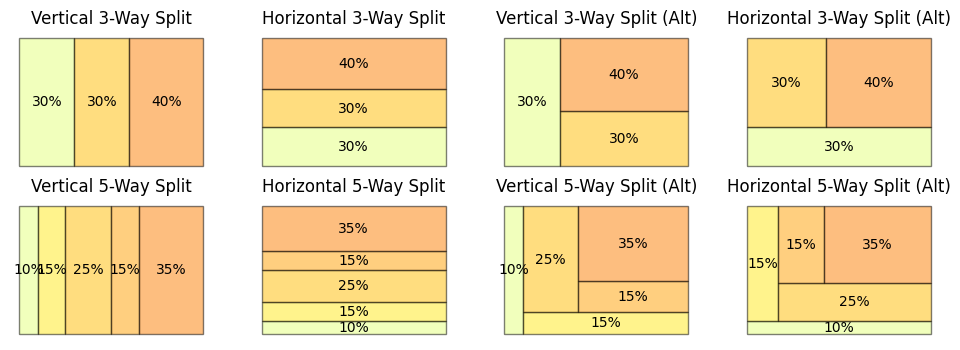

In [34]:
splits = {}

for fractions in ([0.3, 0.3, 0.4], [0.1, 0.15, 0.25, 0.15, 0.35]):
    for alternate in (False, True):
        for direction in ("vertical", "horizontal"):
            alt = " (Alt)" if alternate else ""
            key = f"{direction.capitalize()} {len(fractions)}-Way Split{alt}"
            splits[key] = pc.split(polygon, fractions=fractions, direction=direction, alternate=alternate)

plot_parts(splits, ncolumns=4)

### Treemap Strategy for Grid-Like Splitting

The `treemap` strategy creates compact, grid-like partitions by recursively applying binary splits at alternating orientations. Unlike the default sequential approach that carves parts from edges, treemap splits divide the remaining area proportionally, resulting in more balanced, block-shaped regions. This strategy is ideal for visualizing hierarchical or categorical data that benefits from compact, space-efficient layouts.

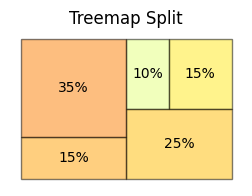

In [35]:
# Treemap creates grid-like patterns
treemap_split = pc.split(polygon, fractions=[0.1, 0.15, 0.25, 0.15, 0.35], strategy="treemap")

plot_parts(
    {"Treemap Split": treemap_split},
    ncolumns=1,
)

## Step 4: Basic Shrinking

The `shrink` function partitions a single geometry into concentric shells and a core, each taking up a user-specified fraction of the geometry's total area. Let's define a simple polygon to demonstrate how the `shrink` function works.

In [36]:
# Create a simple polygon
polygon = Polygon([(0, 0), (10, 0), (10, 5), (0, 5)])

### Create Concentric Shells with Shrink

The `shrink` function generates concentric shells by iteratively shrinking a geometry inward from its perimeter. Provide a single fraction to create a core that occupies that percentage of the original area with a surrounding shell making up the remainder. For multiple shells, pass a list of fractions that sum to 1, where each value represents the area percentage of each concentric layer from **innermost** to **outermost**. This creates visually striking radial visualizations perfect for showing hierarchical or proportional data within a single region.

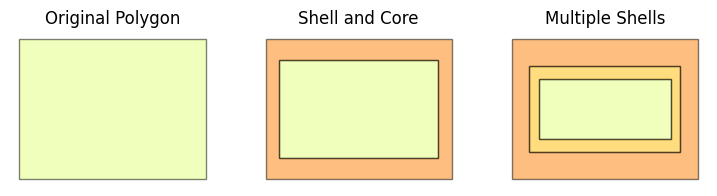

In [37]:
# Partition into a core that takes up 60% and a shell that takes up 40% of the polygon's area
shells1 = pc.shrink(polygon, fractions=0.6)

# Partition into a core that takes up 30% and two shells that take up 20% and 50% of the polygon's area
shells2 = pc.shrink(polygon, fractions=[0.3, 0.2, 0.5])

plot_parts(
    {
        "Original Polygon": polygon,
        "Shell and Core": shells1,
        "Multiple Shells": shells2,
    },
    ncolumns=3,
    label=False,
)

### Shrink Mode Comparison: Area vs Shell

The `shrink` function supports two modes for interpreting fractions. In `area` mode (default), fractions represent direct area proportions of each layer from core to shell. In `shell` mode, fractions are treated as thickness coefficients—since area scales with the square of radius, shell mode creates visually uniform-thickness layers by squaring fractions. This example compares the two modes with a 0.5 fraction to show how interpretation affects layer dimensions.

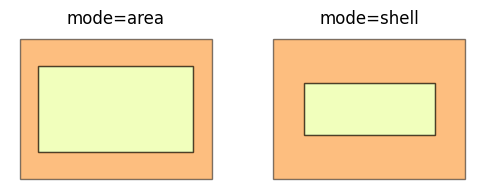

In [38]:
shells = {}

for mode in ["area", "shell"]:
    key = f"mode={mode}"
    shells[key] = pc.shrink(polygon, fractions=0.5, mode=mode)

plot_parts(shells, label=False)

## Step 5: Partitioning Multiple Geometries

The `partition_geometries` function provides efficient batch processing for entire GeoDataFrames, making it ideal for large-scale geographic analysis. To demonstrate its capabilities, we'll use US Census Bureau data to examine poverty levels and racial/ethnic demographics across contiguous U.S. states.

First, we define the variables to retrieve, download, and preprocess the data:

In [39]:
us_states = examples.load_us_census(population=True, race=True, poverty=True, simplify=1000)

### Step 5a: Visualizing Poverty Levels with Shrink Partitioning

Using the preprocessed US states data, we'll create a visualization of poverty levels by partitioning each state into concentric shells. The `partition_geometries` function applies the shrink method to each geometry, creating a core representing the percentage of population below the poverty level and a surrounding shell for those above. We then use `plot_partitions` to visualize these partitions with a custom color palette.

Note of Caution: Since states have vastly different geographic areas, comparing the absolute sizes of cores/shells across states is misleading. Only the relative proportions of below/above poverty levels within each state are directly comparable in this visualization. For meaningful cross-state comparisons, this proportional partitioning may be combined with symbolic or flow cartograms that normalize states by population size first.

In [40]:
partition = pc.partition_geometries(
    us_states, columns=["Below Poverty Level %", "Above Poverty Level %"], method="shrink"
)

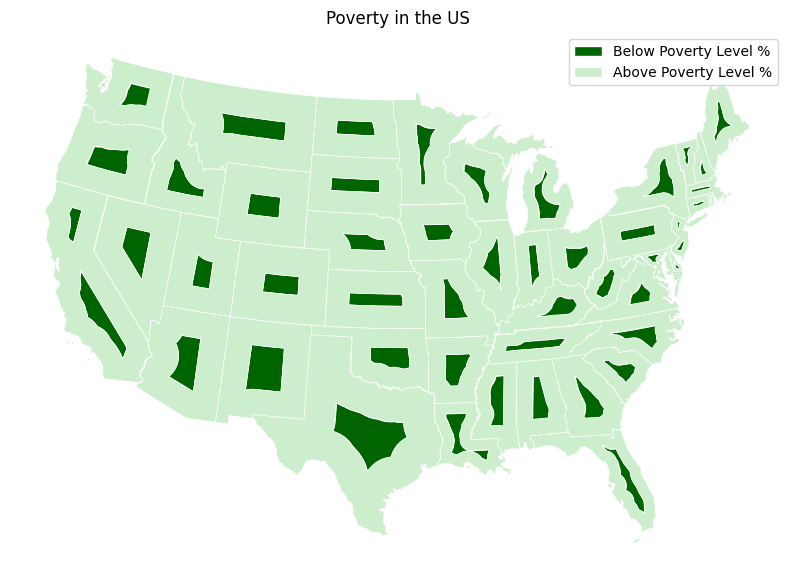

In [41]:
result = pc.plot_partitions(
    partition,
    color_by="category",
    edgecolor="white",
    palette={"Below Poverty Level %": "darkgreen", "Above Poverty Level %": "#cceecc"},
)

result.ax.axis("off")
result.ax.set_title("Poverty in the US");

### Step 5b: Dot Density Cartogram of Poverty Levels

This example uses `plot_dot_density` to create a dot density visualization of poverty levels across US states. The `n_dots=1000` parameter specifies that a fully-filled geometry (with fraction = 1.0) will receive 1000 dots. With `normalization='maximum'`, the state with the maximum total poverty population receives all 1000 dots, while other states get a proportional number of dots scaled to their poverty levels. We use a semi-transparent black for above-poverty dots and opaque red for below-poverty dots to create visual emphasis on areas with high poverty concentrations.

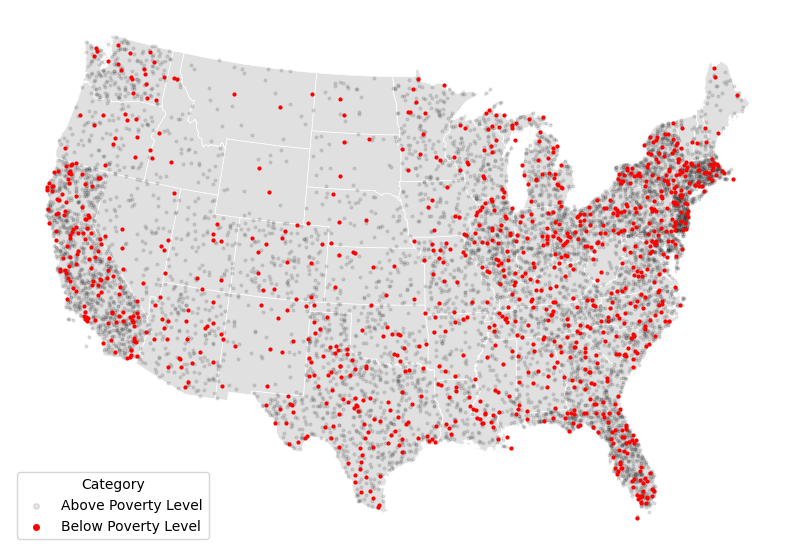

In [42]:
result = pc.plot_dot_density(
    us_states,
    columns=["Above Poverty Level", "Below Poverty Level"],
    n_dots=1000,
    normalization="maximum",
    alpha=[0.1, 1.0],
    palette={"Below Poverty Level": "#ff0000", "Above Poverty Level": "#000000"},
)

result.ax.axis("off");

### Step 5c: Visualizing Minority Group Distributions with Split Partitioning

This example uses the split method with alternating horizontal/vertical splits to visualize the distribution of three major minority groups across US states. The `partition_geometries` function divides each state into partitions proportional to the population share of each minority group.

Normalization Note: The `normalization='row'` parameter ensures each state is completely filled by its partitions, meaning the sum of all minority group shares equals 1.0 for each state. This example explicitly includes only Black or African American, Asian, and Hispanic or Latino populations — other racial/ethnic groups (including White population) are not included in the visualization.

In [43]:
partition = pc.partition_geometries(
    us_states,
    columns=["Black or African American", "Asian", "Hispanic or Latino"],
    method="split",
    direction="horizontal",
    alternate=True,
    normalization="row",
)

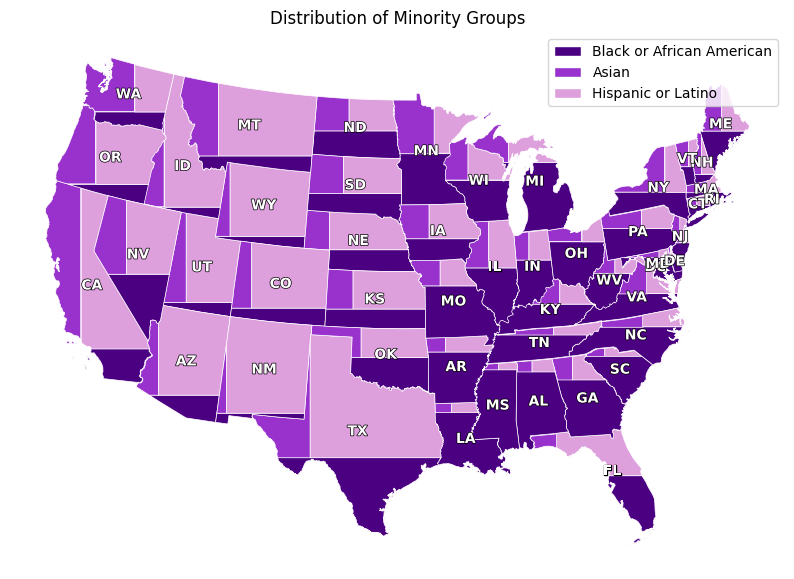

In [44]:
from matplotlib import patheffects

result = pc.plot_partitions(
    partition,
    color_by="category",
    edgecolor="white",
    palette={"Black or African American": "indigo", "Asian": "darkorchid", "Hispanic or Latino": "plum"},
)

result.ax.axis("off")
result.ax.set_title("Distribution of Minority Groups")

for _, row in us_states.iterrows():
    h = result.ax.text(
        row.geometry.centroid.x,
        row.geometry.centroid.y,
        row["State Abbreviation"],
        va="center",
        ha="center",
        color="white",
        fontweight="bold",
    )

    h.set(path_effects=[patheffects.withStroke(linewidth=1, foreground="k")])

## Additional Resources

- [API Reference: partition](../../reference/proportional_cartogram/partition/)
- [API Reference: splitting](../../reference/proportional_cartogram/splitting/)
- [API Reference: shrinking](../../reference/proportional_cartogram/shrinking/)
- [API Reference: dot density](../../reference/proportional_cartogram/dot_density/)
- [API Reference: visualization](../../reference/proportional_cartogram/visualization/)

---

*This notebook is part of the carto-flow documentation. Report issues at https://github.com/fkloosterman/carto-flow/issues*